<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/20_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Monthly Milk Production Forecasting**
##**[Using RNN, LSTM, and GRU Deep Learning Models]**

**Data Preparation**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("monthly_milk_production.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nData types:")
print(df.dtypes)

Shape: (168, 2)

Columns: ['Date', 'Production']

First 5 rows:


,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727



Last 5 rows:


,Date,Production
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797
167,1975-12-01,843



Data types:
Date          datetime64[ns]
Production             int64
dtype: object


**Data Quality**

In [ ]:

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df["Production"].describe())

q1 = df["Production"].quantile(0.25)
q3 = df["Production"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["Production"] < lower_bound) |
    (df["Production"] > upper_bound)
]

print("\nPotential outliers:", len(outliers))
display(outliers)

Missing values:
Date          0
Production    0
dtype: int64

Duplicate rows: 0

Descriptive statistics:


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000



Potential outliers: 0


,Date,Production


**Trend Analysis**

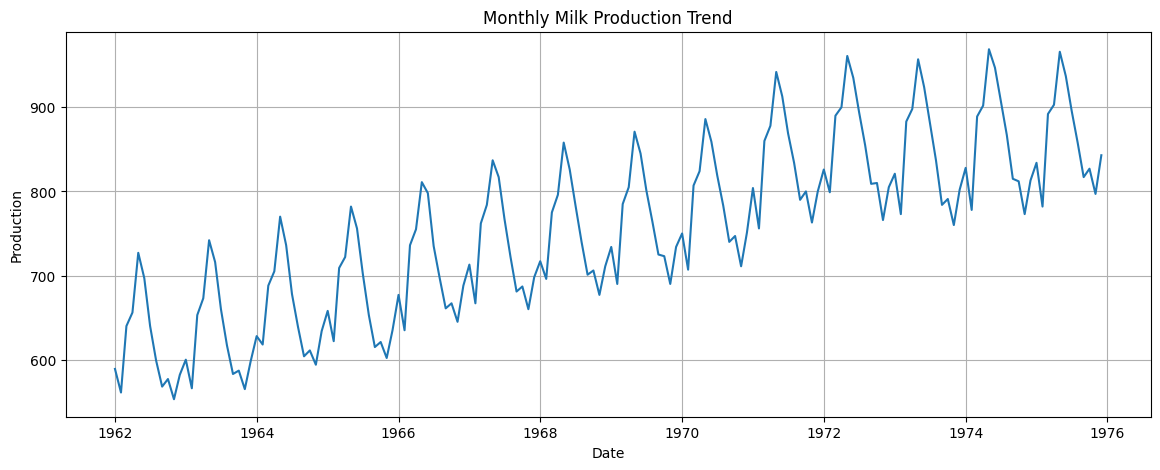

In [ ]:

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Production"])
plt.title("Monthly Milk Production Trend")
plt.xlabel("Date")
plt.ylabel("Production")
plt.grid(True)
plt.show()

**Seasonality Analysis**

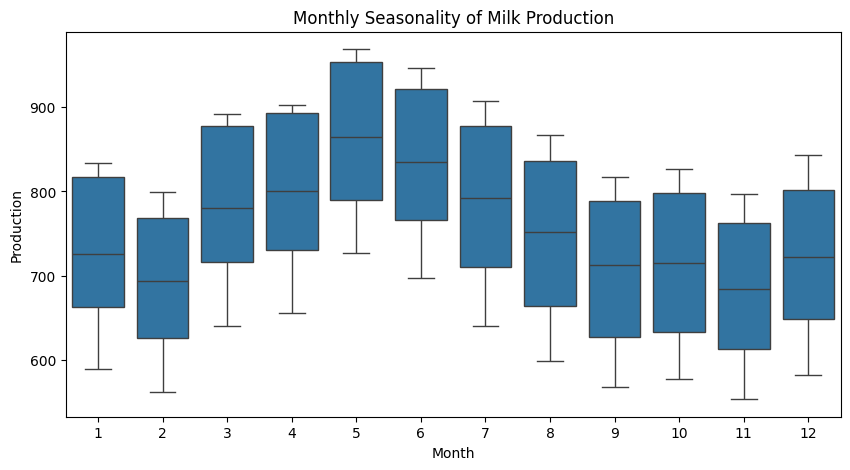

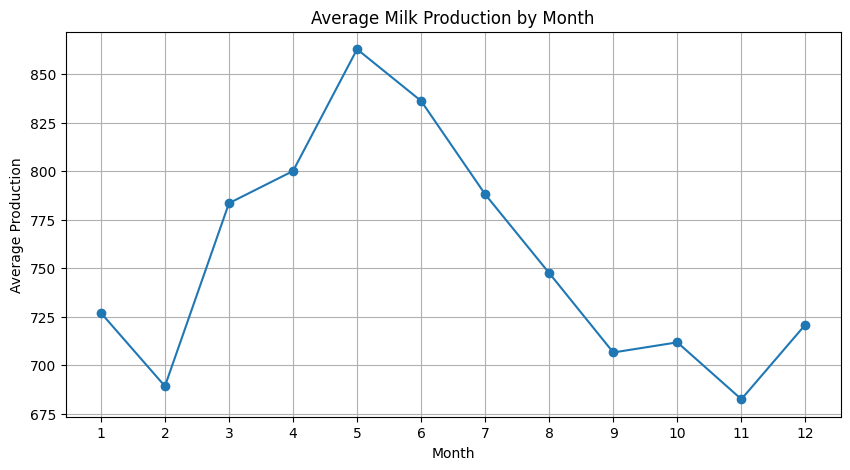

In [ ]:

df["Month"] = df["Date"].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Month", y="Production")
plt.title("Monthly Seasonality of Milk Production")
plt.xlabel("Month")
plt.ylabel("Production")
plt.show()

monthly_average = df.groupby("Month")["Production"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_average.index, monthly_average.values, marker="o")
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

**Anomaly Visualization**

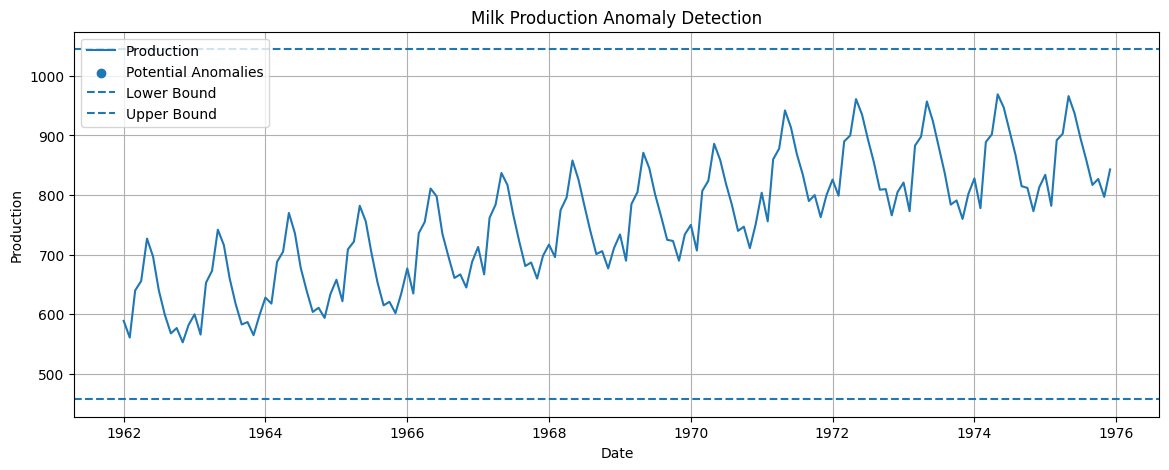

Potential anomaly dates:


,Date,Production


In [ ]:

anomaly_mask = (
    (df["Production"] < lower_bound) |
    (df["Production"] > upper_bound)
)

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Production"], label="Production")
plt.scatter(
    df.loc[anomaly_mask, "Date"],
    df.loc[anomaly_mask, "Production"],
    label="Potential Anomalies"
)
plt.axhline(lower_bound, linestyle="--", label="Lower Bound")
plt.axhline(upper_bound, linestyle="--", label="Upper Bound")
plt.title("Milk Production Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

print("Potential anomaly dates:")
display(df.loc[anomaly_mask, ["Date", "Production"]])

**Data Scaling**

In [ ]:

values = df["Production"].values.reshape(-1, 1)

train_end = int(len(values) * 0.70)
validation_end = int(len(values) * 0.85)

scaler = MinMaxScaler()
scaler.fit(values[:train_end])

scaled_values = scaler.transform(values)

print("Total observations:", len(values))
print("Training observations:", train_end)
print("Validation observations:", validation_end - train_end)
print("Testing observations:", len(values) - validation_end)
print("Scaled minimum:", scaled_values.min())
print("Scaled maximum:", scaled_values.max())

Total observations: 168
Training observations: 117
Validation observations: 25
Testing observations: 26
Scaled minimum: 0.0
Scaled maximum: 1.0694087403598969


**Time Window Creation**

In [ ]:

def create_sequences(data, window_size):
    X = []
    y = []
    indices = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
        indices.append(i)

    return np.array(X), np.array(y), np.array(indices)

window_size = 12

X, y, indices = create_sequences(
    scaled_values,
    window_size
)

train_mask = indices < train_end
validation_mask = (
    (indices >= train_end) &
    (indices < validation_end)
)
test_mask = indices >= validation_end

X_train = X[train_mask]
y_train = y[train_mask]

X_validation = X[validation_mask]
y_validation = y[validation_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Training input shape:", X_train.shape)
print("Validation input shape:", X_validation.shape)
print("Testing input shape:", X_test.shape)
print("Model input dimensions:", X_train.shape[1:])

Training input shape: (105, 12, 1)
Validation input shape: (25, 12, 1)
Testing input shape: (26, 12, 1)
Model input dimensions: (12, 1)


**Basic RNN**

In [ ]:

def build_rnn(units, window):
    model = Sequential([
        SimpleRNN(
            units,
            activation="tanh",
            input_shape=(window, 1)
        ),
        Dropout(0.1),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

rnn_model = build_rnn(32, window_size)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0436 - val_loss: 0.0130
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0269 - val_loss: 0.0309
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0242 - val_loss: 0.0252
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0208 - val_loss: 0.0107
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0167 - val_loss: 0.0206
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0132 - val_loss: 0.0156
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169 - val_loss: 0.0135
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145 - val_loss: 0.0102
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0159 - val_loss: 0.0094
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0134 - val_loss: 0.0106
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0094 - val_loss: 0.0099
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0104 - val_loss: 0.0079
Epoch 13/50


**LSTM**

In [ ]:

def build_lstm(units, window):
    model = Sequential([
        LSTM(
            units,
            activation="tanh",
            input_shape=(window, 1)
        ),
        Dropout(0.1),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

lstm_model = build_lstm(32, window_size)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.2589 - val_loss: 0.4673
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1450 - val_loss: 0.2303
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0680 - val_loss: 0.0804
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0385 - val_loss: 0.0290
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0392 - val_loss: 0.0290
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0408 - val_loss: 0.0296
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0341 - val_loss: 0.0387
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0338 - val_loss: 0.0418
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0333 - val_loss: 0.0365
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0337 - val_loss: 0.0319
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0346 - val_loss: 0.0299
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0296 - val_loss: 0.0288
E

**GRU**

In [ ]:

def build_gru(units, window):
    model = Sequential([
        GRU(
            units,
            activation="tanh",
            input_shape=(window, 1)
        ),
        Dropout(0.1),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

gru_model = build_gru(32, window_size)

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.1761 - val_loss: 0.2886
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0742 - val_loss: 0.1024
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0311 - val_loss: 0.0326
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0320 - val_loss: 0.0242
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0380 - val_loss: 0.0261
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0277 - val_loss: 0.0367
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0269 - val_loss: 0.0440
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0291 - val_loss: 0.0428
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0272 - val_loss: 0.0378
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0267 - val_loss: 0.0325
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0243 - val_loss: 0.0303
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0232 - val_loss: 0.0307


**Hyperparameter Tuning**

In [ ]:

configurations = [
    {"window": 6, "units": 16, "batch": 16, "epochs": 30},
    {"window": 6, "units": 32, "batch": 16, "epochs": 40},
    {"window": 12, "units": 16, "batch": 16, "epochs": 30},
    {"window": 12, "units": 32, "batch": 32, "epochs": 40}
]

def prepare_window_data(window):
    X_temp, y_temp, index_temp = create_sequences(
        scaled_values,
        window
    )

    train_mask = index_temp < train_end
    validation_mask = (
        (index_temp >= train_end) &
        (index_temp < validation_end)
    )
    test_mask = index_temp >= validation_end

    return (
        X_temp[train_mask],
        y_temp[train_mask],
        X_temp[validation_mask],
        y_temp[validation_mask],
        X_temp[test_mask],
        y_temp[test_mask]
    )

def create_model(model_type, units, window):
    if model_type == "RNN":
        return build_rnn(units, window)

    if model_type == "LSTM":
        return build_lstm(units, window)

    return build_gru(units, window)

tuning_results = []
best_models = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    best_validation_loss = np.inf
    best_model = None
    best_configuration = None

    for configuration in configurations:

        Xtr, ytr, Xv, yv, Xt, yt = prepare_window_data(
            configuration["window"]
        )

        model = create_model(
            model_type,
            configuration["units"],
            configuration["window"]
        )

        history = model.fit(
            Xtr,
            ytr,
            validation_data=(Xv, yv),
            epochs=configuration["epochs"],
            batch_size=configuration["batch"],
            callbacks=[
                EarlyStopping(
                    monitor="val_loss",
                    patience=5,
                    restore_best_weights=True
                )
            ],
            verbose=0
        )

        validation_loss = min(
            history.history["val_loss"]
        )

        tuning_results.append({
            "Model": model_type,
            "Window Size": configuration["window"],
            "Units": configuration["units"],
            "Batch Size": configuration["batch"],
            "Epochs": configuration["epochs"],
            "Validation Loss": validation_loss
        })

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_model = model
            best_configuration = configuration

    best_models[model_type] = {
        "model": best_model,
        "configuration": best_configuration
    }

tuning_results_df = pd.DataFrame(tuning_results)

display(
    tuning_results_df.sort_values(
        ["Model", "Validation Loss"]
    )
)

print("\nBest configurations:")

for model_type, result in best_models.items():
    print(model_type, ":", result["configuration"])

,Model,Window Size,Units,Batch Size,Epochs,Validation Loss
8,GRU,6,16,16,30,0.023185
11,GRU,12,32,32,40,0.024485
9,GRU,6,32,16,40,0.025242
10,GRU,12,16,16,30,0.039940
7,LSTM,12,32,32,40,0.029231
5,LSTM,6,32,16,40,0.035858
6,LSTM,12,16,16,30,0.045524
4,LSTM,6,16,16,30,0.056955
3,RNN,12,32,32,40,0.003763
2,RNN,12,16,16,30,0.007910



Best configurations:
RNN : {'window': 12, 'units': 32, 'batch': 32, 'epochs': 40}
LSTM : {'window': 12, 'units': 32, 'batch': 32, 'epochs': 40}
GRU : {'window': 6, 'units': 16, 'batch': 16, 'epochs': 30}


**Model Evaluation**

In [ ]:

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual).flatten()
    predicted = np.asarray(predicted).flatten()

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) /
            np.where(actual == 0, 1, actual)
        )
    ) * 100

    return rmse, mae, mape

evaluation_results = []
test_predictions = {}

for model_type, result in best_models.items():

    model = result["model"]
    window = result["configuration"]["window"]

    _, _, _, _, Xtest, ytest = prepare_window_data(
        window
    )

    predictions = model.predict(
        Xtest,
        verbose=0
    )

    actual_original = scaler.inverse_transform(ytest)
    predicted_original = scaler.inverse_transform(predictions)

    rmse, mae, mape = calculate_metrics(
        actual_original,
        predicted_original
    )

    evaluation_results.append({
        "Model": model_type,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

    test_predictions[model_type] = {
        "actual": actual_original.flatten(),
        "predicted": predicted_original.flatten()
    }

evaluation_df = pd.DataFrame(
    evaluation_results
).sort_values("RMSE")

display(evaluation_df)

,Model,RMSE,MAE,MAPE
0,RNN,26.619218,22.085379,2.597341
2,GRU,61.238562,48.185662,5.450285
1,LSTM,68.597483,60.502963,7.034007


**Actual vs Predicted**

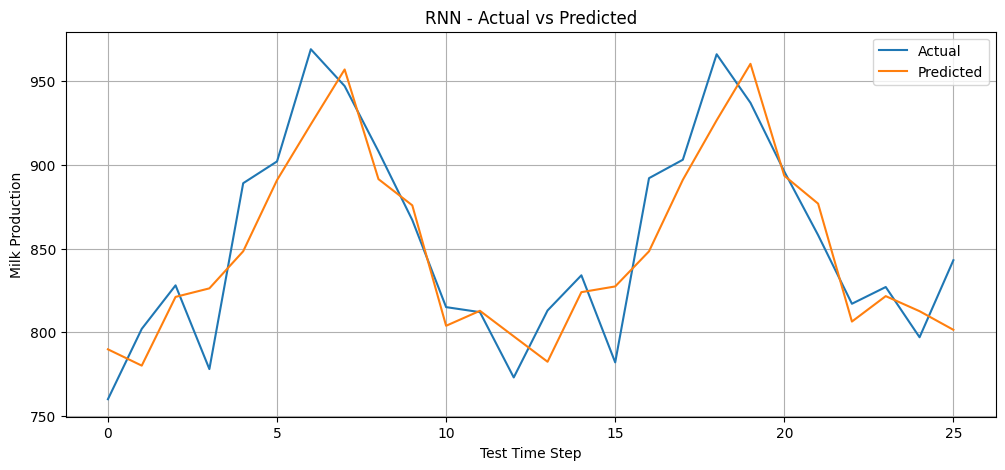

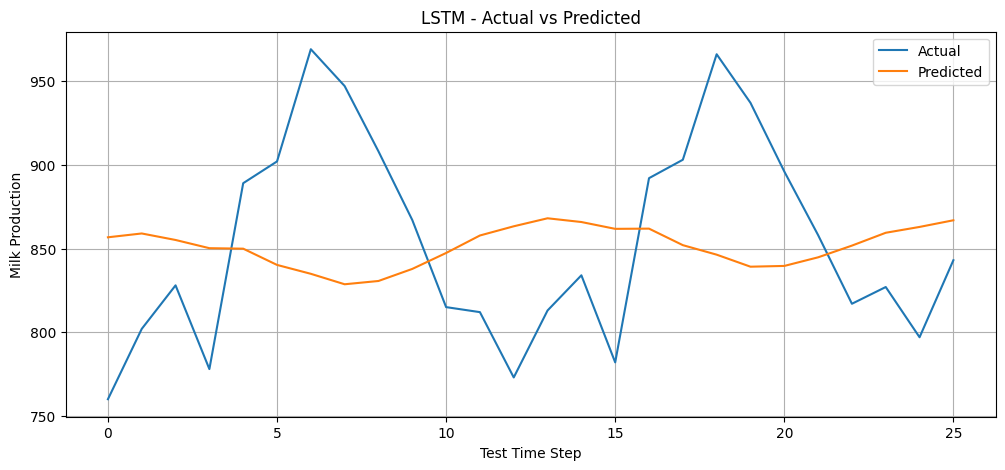

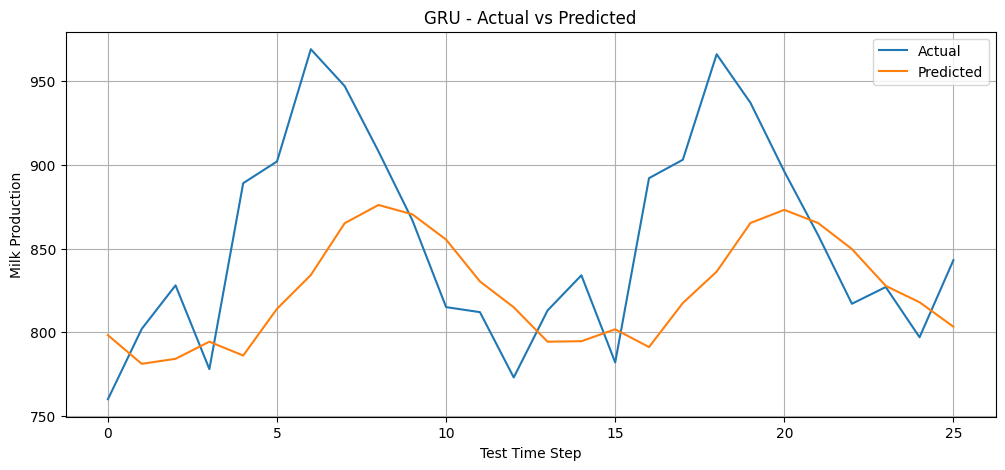

In [ ]:

for model_type, result in test_predictions.items():

    plt.figure(figsize=(12, 5))

    plt.plot(
        result["actual"],
        label="Actual"
    )

    plt.plot(
        result["predicted"],
        label="Predicted"
    )

    plt.title(
        f"{model_type} - Actual vs Predicted"
    )

    plt.xlabel("Test Time Step")
    plt.ylabel("Milk Production")
    plt.legend()
    plt.grid(True)
    plt.show()

**Model Comparison**

,Model,RMSE,MAE,MAPE
0,RNN,26.619218,22.085379,2.597341
2,GRU,61.238562,48.185662,5.450285
1,LSTM,68.597483,60.502963,7.034007


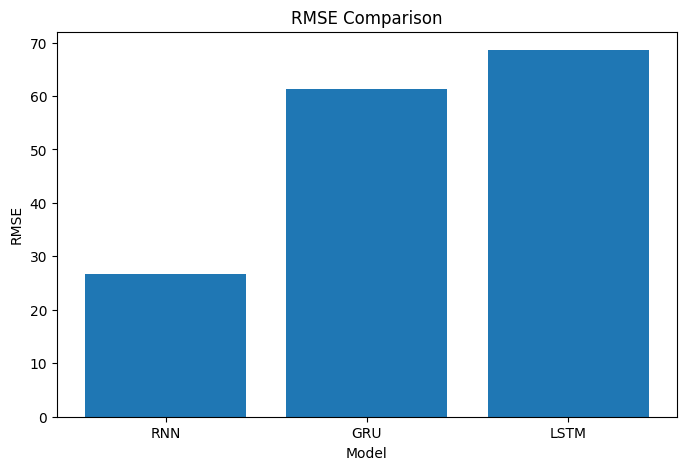

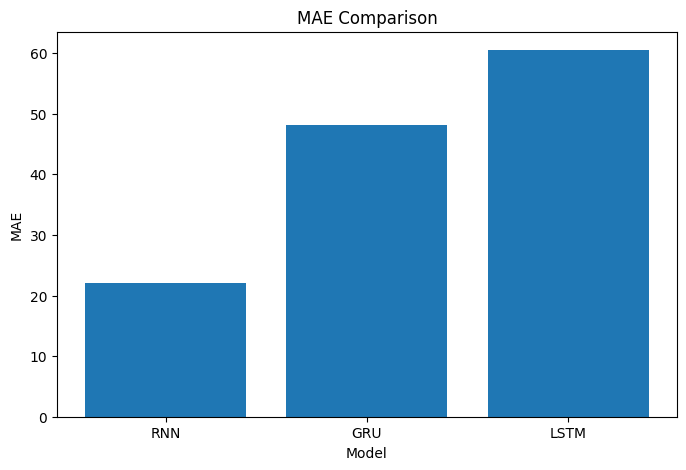

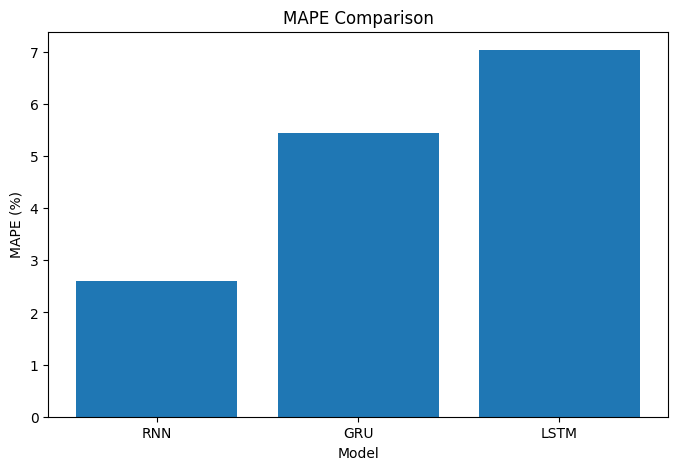

In [ ]:

display(evaluation_df)

plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_df["Model"],
    evaluation_df["RMSE"]
)
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_df["Model"],
    evaluation_df["MAE"]
)
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_df["Model"],
    evaluation_df["MAPE"]
)
plt.title("MAPE Comparison")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.show()

**Best Model Selection**

In [ ]:

best_model_name = evaluation_df.iloc[0]["Model"]

best_model = best_models[
    best_model_name
]["model"]

best_window = best_models[
    best_model_name
]["configuration"]["window"]

print("Best model:", best_model_name)
print("Best window size:", best_window)

print("\nBest model performance:")
display(
    evaluation_df[
        evaluation_df["Model"] == best_model_name
    ]
)

Best model: RNN
Best window size: 12

Best model performance:


,Model,RMSE,MAE,MAPE
0,RNN,26.619218,22.085379,2.597341


**Forecast Next 12 Months**

In [ ]:

history_values = list(
    scaled_values.flatten()
)

future_scaled = []

for _ in range(12):

    input_sequence = np.array(
        history_values[-best_window:]
    ).reshape(
        1,
        best_window,
        1
    )

    next_value = best_model.predict(
        input_sequence,
        verbose=0
    )[0, 0]

    future_scaled.append(next_value)
    history_values.append(next_value)

future_predictions = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
).flatten()

future_dates = pd.date_range(
    start=df["Date"].max() + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions
})

display(forecast_df)

,Date,Forecasted Production
0,1976-01-01,843.048157
1,1976-02-01,831.574707
2,1976-03-01,874.244019
3,1976-04-01,879.050293
4,1976-05-01,909.587830
5,1976-06-01,910.970886
6,1976-07-01,890.894958
7,1976-08-01,874.770874
8,1976-09-01,837.323181
9,1976-10-01,835.462646


**Forecast Uncertainty**

In [ ]:

best_test_predictions = test_predictions[
    best_model_name
]

residuals = (
    best_test_predictions["actual"] -
    best_test_predictions["predicted"]
)

residual_std = np.std(residuals)

forecast_df["Lower Bound"] = (
    forecast_df["Forecasted Production"] -
    1.96 * residual_std
)

forecast_df["Upper Bound"] = (
    forecast_df["Forecasted Production"] +
    1.96 * residual_std
)

display(forecast_df)

,Date,Forecasted Production,Lower Bound,Upper Bound
0,1976-01-01,843.048157,791.721252,894.375061
1,1976-02-01,831.574707,780.247803,882.901611
2,1976-03-01,874.244019,822.917114,925.570923
3,1976-04-01,879.050293,827.723389,930.377197
4,1976-05-01,909.587830,858.260925,960.914734
5,1976-06-01,910.970886,859.643982,962.297791
6,1976-07-01,890.894958,839.568054,942.221863
7,1976-08-01,874.770874,823.443970,926.097778
8,1976-09-01,837.323181,785.996277,888.650085
9,1976-10-01,835.462646,784.135742,886.789551


**Forecast Visualization**

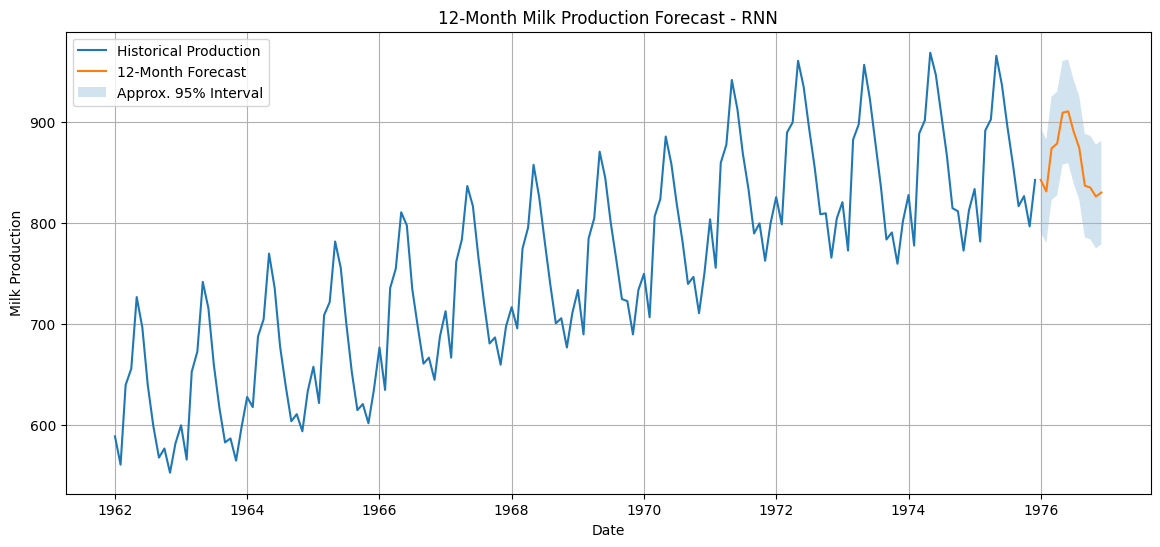

In [ ]:

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted Production"],
    label="12-Month Forecast"
)

plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower Bound"],
    forecast_df["Upper Bound"],
    alpha=0.2,
    label="Approx. 95% Interval"
)

plt.title(
    f"12-Month Milk Production Forecast - {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

##**Business Insights**

* The forecasting model predicts milk production for the next 12 months using historical monthly production data.

* The model with the lowest RMSE provides the best forecasting performance among the tested RNN, LSTM and GRU models.

* The forecasts can help the dairy business with supply-chain planning, inventory and storage management, workforce planning, production scheduling and resource allocation.

* The observed seasonal pattern can help management prepare for periods of relatively high or low milk production.

* The approximate forecast interval can provide an additional range for planning under uncertainty.

* The business should compare predicted production with expected demand and available storage capacity to reduce waste, prepare for shortages and improve operational planning.